<a href="https://colab.research.google.com/github/mandarisumanth86-star/Calculator1/blob/main/E_Commerce_Customer_Intelligence_%26_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-Commerce Customer Intelligence &     Recommendation System

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/online+retail+ii.zip'
data_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_path)

print("Dataset extracted successfully!")
print(os.listdir(data_path))

Dataset extracted successfully!
['online_retail_II.xlsx', 'retail_500k.csv', 'customer_transactions_clean.csv', 'customer_rfm_segments.csv', 'customer_product_matrix.csv', 'customer_similarity_matrix.csv', 'sample_recommendations.csv']


In [ ]:
# Load the Excel workbook
file_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data/online_retail_II.xlsx'

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [ ]:
# Load both sheets
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name='Year 2009-2010'
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name='Year 2010-2011'
)

print("2009-2010:", df_2009_2010.shape)
print("2010-2011:", df_2010_2011.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [ ]:
# Check the columns
print(df_2009_2010.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [ ]:
# First, combine the two sheets
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Total transactions:", len(df))

Total transactions: 1067371


In [ ]:
# Convert the date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df = df.sort_values('InvoiceDate').reset_index(drop=True)

print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


In [ ]:
# Select our 500,000 transactions
df_500k = df.iloc[:500000].copy()

print("Selected transactions:", len(df_500k))

Selected transactions: 500000


In [ ]:
# Save our project dataset
output_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data/retail_500k.csv'

df_500k.to_csv(output_path, index=False)

print("500K dataset saved successfully!")

500K dataset saved successfully!


In [ ]:
# Load our 500K dataset
project_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data/retail_500k.csv'

df = pd.read_csv(project_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 500000
Columns: 8


In [ ]:
# See the first 5 records
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      500000 non-null  object 
 1   StockCode    500000 non-null  object 
 2   Description  497184 non-null  object 
 3   Quantity     500000 non-null  int64  
 4   InvoiceDate  500000 non-null  object 
 5   Price        500000 non-null  float64
 6   Customer ID  400300 non-null  float64
 7   Country      500000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 30.5+ MB


In [ ]:
# Check missing values
df.isnull().sum()


,0
Invoice,0
StockCode,0
Description,2816
Quantity,0
InvoiceDate,0
Price,0
Customer ID,99700
Country,0


In [ ]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6508


In [ ]:
# Investigate the missing Customer IDs
missing_customer = df[df['Customer ID'].isnull()]

print("Rows with missing Customer ID:", len(missing_customer))

missing_customer.head()
missing_customer['Country'].value_counts().head(10)

Rows with missing Customer ID: 99700


,count
Country,
United Kingdom,98213
EIRE,949
United Arab Emirates,114
Portugal,77
Hong Kong,76
Bahrain,65
France,62
RSA,46
Bermuda,34


In [ ]:
# Investigate the duplicate rows
duplicates = df[df.duplicated(keep=False)]

print("Rows involved in duplicates:", len(duplicates))

duplicates.head(10)

Rows involved in duplicates: 12595


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
361,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
363,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
364,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
365,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
366,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
370,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
373,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
377,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
382,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [ ]:
# Check cancelled invoices
df['Invoice'].astype(str).str.startswith('C').value_counts()
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]

print("Cancelled transactions:", len(cancelled))

cancelled.head()

Cancelled transactions: 9756


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
180,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
181,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [ ]:
# Check negative quantities
print("Negative quantity:", (df['Quantity'] < 0).sum())
print("Zero quantity:", (df['Quantity'] == 0).sum())

Negative quantity: 11810
Zero quantity: 0


In [ ]:
# Check unusual prices
print("Zero price:", (df['Price'] == 0).sum())
print("Negative price:", (df['Price'] < 0).sum())

Zero price: 3503
Negative price: 3


In [ ]:
# Investigate the 3 negative prices
negative_price = df[df['Price'] < 0]

print("Negative price transactions:", len(negative_price))

negative_price

Negative price transactions: 3


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [ ]:
# Investigate zero-price transactions
zero_price = df[df['Price'] == 0]

print("Zero-price transactions:", len(zero_price))

zero_price[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(20)

Zero-price transactions: 3503


,Invoice,StockCode,Description,Quantity,Price,Customer ID
267,489463,71477,short,-240,0.0,NaN
276,489464,21733,85123a mixed,-96,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3161,489659,21350,NaN,230,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
3744,489781,84292,NaN,17,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN


In [ ]:
# Check the relationship between cancellations and negative quantities
cancelled_negative = df[
    df['Invoice'].astype(str).str.startswith('C') &
    (df['Quantity'] < 0)
]

print("Cancelled invoices with negative quantity:", len(cancelled_negative))
negative_not_cancelled = df[
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Quantity'] < 0)
]

print("Negative quantities without C invoice:", len(negative_not_cancelled))

Cancelled invoices with negative quantity: 9755
Negative quantities without C invoice: 2055


In [ ]:
# Check duplicate nature
df.duplicated().sum()
df_no_duplicates = df.drop_duplicates()

print("Original rows:", len(df))
print("After removing exact duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df) - len(df_no_duplicates))

Original rows: 500000
After removing exact duplicates: 493492
Rows removed: 6508


In [ ]:
# Investigate zero-price records properly
zero_price_summary = pd.DataFrame({
    'Total': [len(zero_price)],
    'Positive Quantity': [(zero_price['Quantity'] > 0).sum()],
    'Negative Quantity': [(zero_price['Quantity'] < 0).sum()],
    'With Customer ID': [zero_price['Customer ID'].notna().sum()],
    'Without Customer ID': [zero_price['Customer ID'].isna().sum()]
})

zero_price_summary

,Total,Positive Quantity,Negative Quantity,With Customer ID,Without Customer ID
0,3503,1448,2055,30,3473


In [ ]:
# Check the 2,055 negative quantities without C invoices
negative_not_cancelled[
    ['Invoice', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'Price',
     'Customer ID', 'Country']
].head(20)
negative_not_cancelled['Customer ID'].notna().sum()

np.int64(0)

In [ ]:
# Check how many positive-purchase transactions have Customer ID
positive_sales = df[
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
]

print("Positive sales:", len(positive_sales))
print("Positive sales with Customer ID:",
      positive_sales['Customer ID'].notna().sum())

Positive sales: 486739
Positive sales with Customer ID: 390849


In [ ]:
# Check the number of unique customers
print(
    "Unique customers:",
    positive_sales['Customer ID'].nunique()
)
print(
    "Unique products:",
    positive_sales['StockCode'].nunique()
)

Unique customers: 4257
Unique products: 4240


In [ ]:
# Create the cleaned customer dataset
# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

# Keep genuine positive purchases with known customers
customer_df = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['Price'] > 0) &
    (df_clean['Customer ID'].notna())
].copy()

print("Clean customer transactions:", len(customer_df))
print("Unique customers:", customer_df['Customer ID'].nunique())
print("Unique products:", customer_df['StockCode'].nunique())

Clean customer transactions: 384456
Unique customers: 4257
Unique products: 4009


In [ ]:
# Convert InvoiceDate properly
customer_df['InvoiceDate'] = pd.to_datetime(
    customer_df['InvoiceDate']
)

print(customer_df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [ ]:
# Create Revenue
customer_df['Revenue'] = (
    customer_df['Quantity'] * customer_df['Price']
)

customer_df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [ ]:
# Save the cleaned dataset
clean_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data/customer_transactions_clean.csv'

customer_df.to_csv(
    clean_path,
    index=False
)

print("Clean customer dataset saved successfully!")

Clean customer dataset saved successfully!


In [ ]:
# Basic statistics
customer_df[['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,384456.000000,384456.000000,384456.000000
mean,13.879198,3.313950,21.939542
std,99.252226,35.777968,77.428326
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,5.000000
50%,5.000000,1.950000,12.500000
75%,12.000000,3.750000,19.500000
max,19152.000000,10953.500000,15818.400000


In [ ]:
# Total revenue
total_revenue = customer_df['Revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8434788.694000002


In [ ]:
# Number of unique orders
total_orders = customer_df['Invoice'].nunique()

print("Total Orders:", total_orders)

Total Orders: 18314


In [ ]:
# Average Order Value
average_order_value = total_revenue / total_orders

print("Average Order Value:", average_order_value)

Average Order Value: 460.5650701102982


In [ ]:
# Monthly Revenue
customer_df['YearMonth'] = customer_df['InvoiceDate'].dt.to_period('M')
monthly_revenue = (
    customer_df
    .groupby('YearMonth')['Revenue']
    .sum()
)

monthly_revenue

,Revenue
YearMonth,
2009-12,683504.010
2010-01,555802.672
2010-02,504558.956
2010-03,696978.471
2010-04,591982.002
2010-05,597833.380
2010-06,636371.130
2010-07,589736.170
2010-08,602224.600


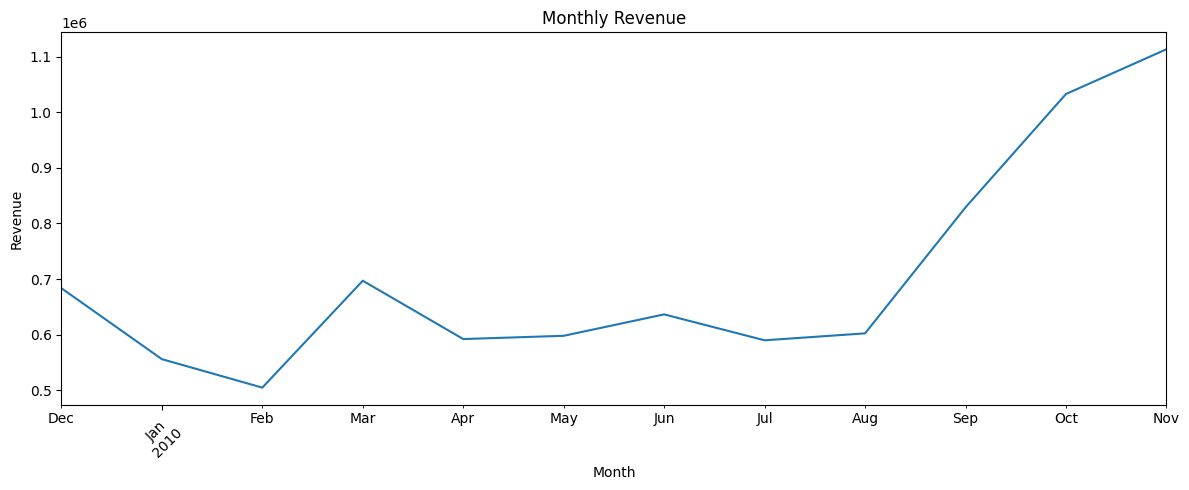

In [ ]:
# Plot monthly revenue
plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

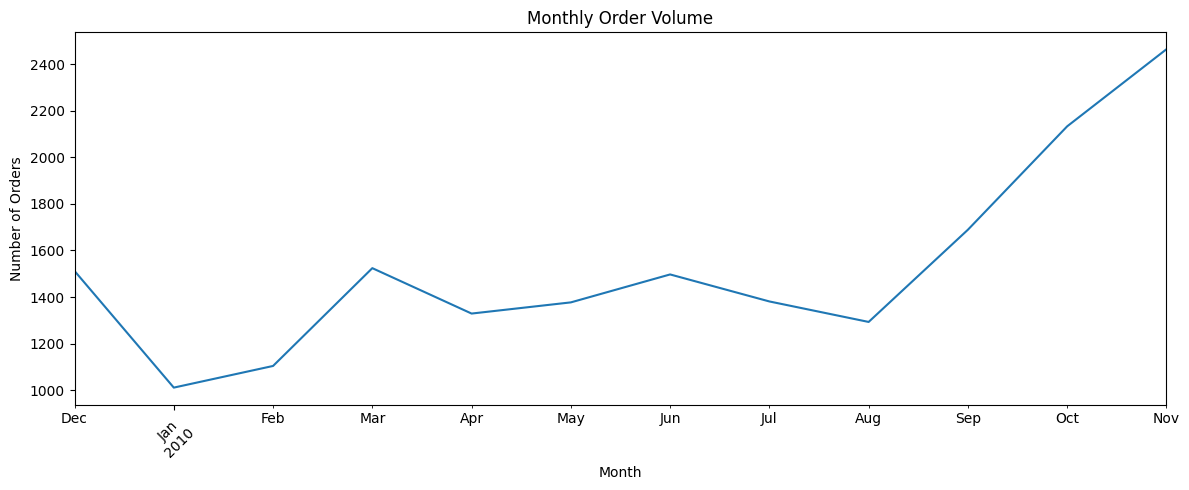

In [ ]:
# Calculate monthly orders
monthly_orders = (
    customer_df
    .groupby('YearMonth')['Invoice']
    .nunique()
)

monthly_orders
plt.figure(figsize=(12, 5))

monthly_orders.plot()

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

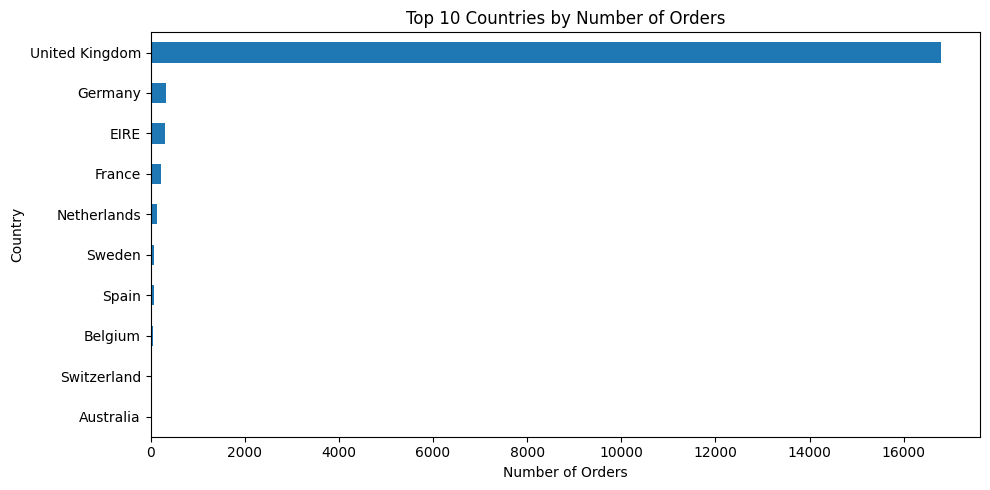

In [ ]:
# Top 10 countries by number of orders
country_orders = (
    customer_df
    .groupby('Country')['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

country_orders
plt.figure(figsize=(10, 5))

country_orders.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

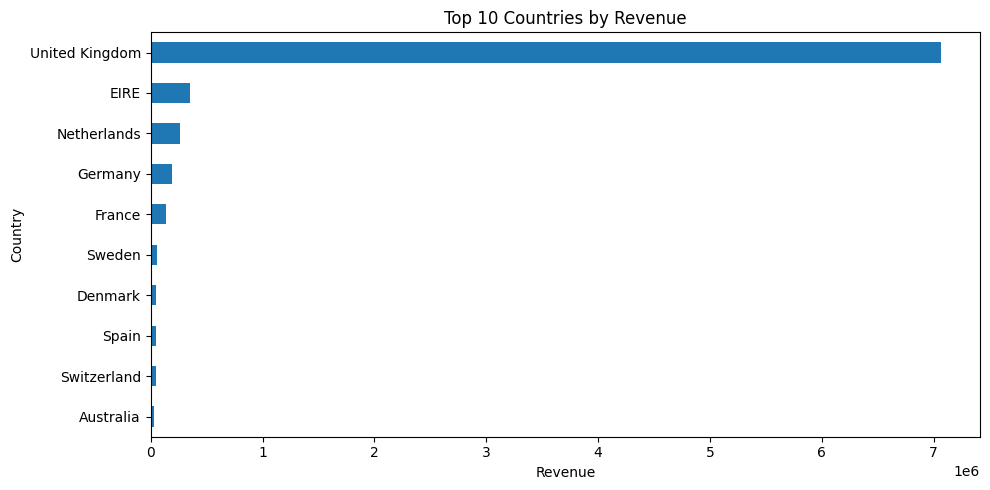

In [ ]:
# Top 10 countries by revenue
country_revenue = (
    customer_df
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue
plt.figure(figsize=(10, 5))

country_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 products by quantity sold
top_products_quantity = (
    customer_df
    .groupby('StockCode')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity
product_names = (
    customer_df[['StockCode', 'Description']]
    .dropna()
    .drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
)

top_products_quantity.index = top_products_quantity.index.map(product_names)

top_products_quantity

,Quantity
StockCode,
PACK OF 72 RETRO SPOT CAKE CASES,55979
WHITE HANGING HEART T-LIGHT HOLDER,54740
WORLD WAR 2 GLIDERS ASSTD DESIGNS,50674
BROCADE RING PURSE,47155
JUMBO BAG RED WHITE SPOTTY,46538
ASSORTED COLOUR BIRD ORNAMENT,42843
60 TEATIME FAIRY CAKE CASES,35128
PACK OF 60 PINK PAISLEY CAKE CASES,30169
"POPCORN HOLDER , SMALL",27737


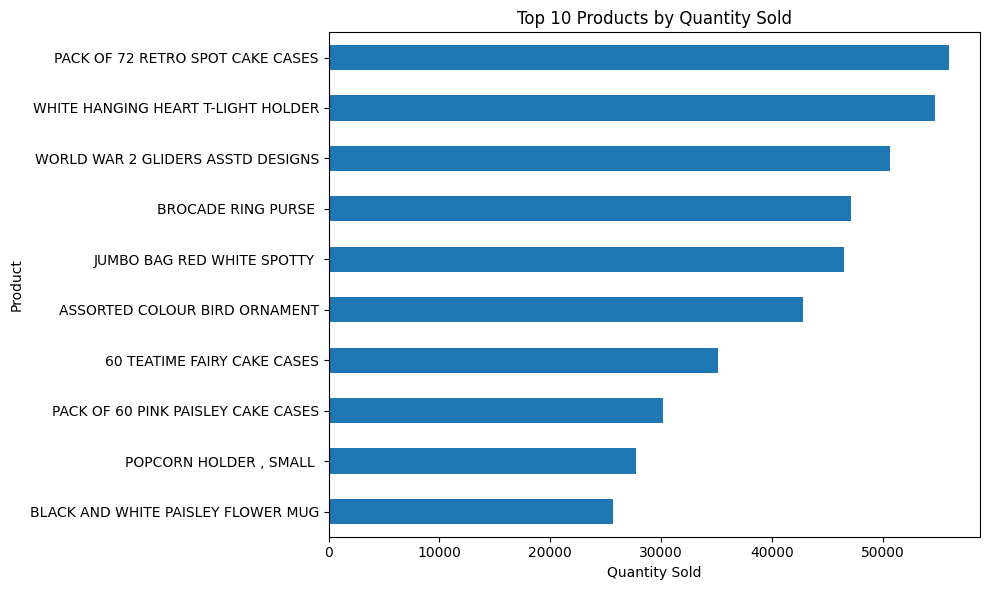

In [ ]:
# Visualize top products by quantity
plt.figure(figsize=(10, 6))

top_products_quantity.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

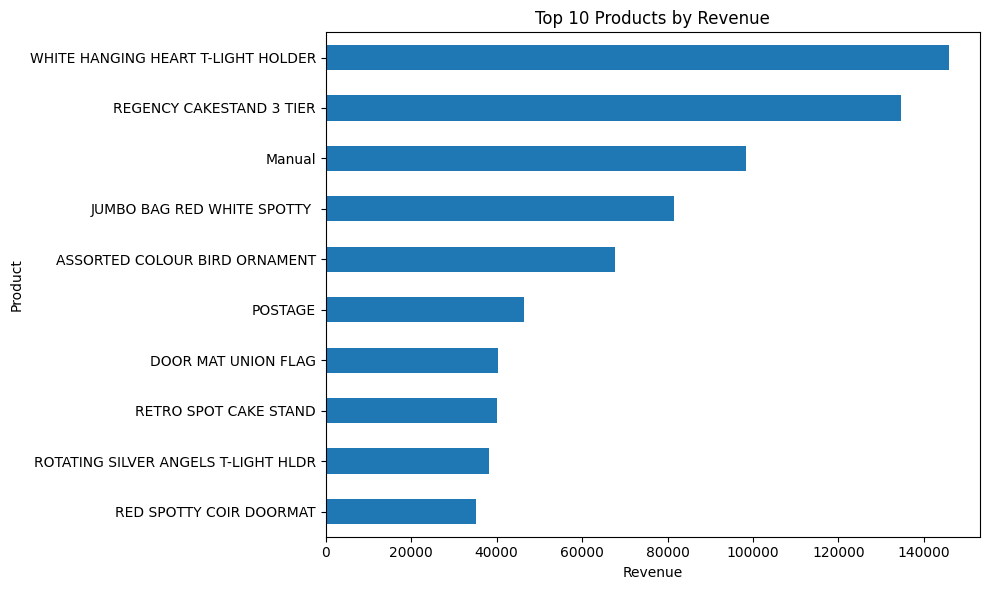

In [ ]:
# Top 10 products by revenue
top_products_revenue = (
    customer_df
    .groupby('StockCode')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue
top_products_revenue.index = top_products_revenue.index.map(product_names)

top_products_revenue
plt.figure(figsize=(10, 6))

top_products_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

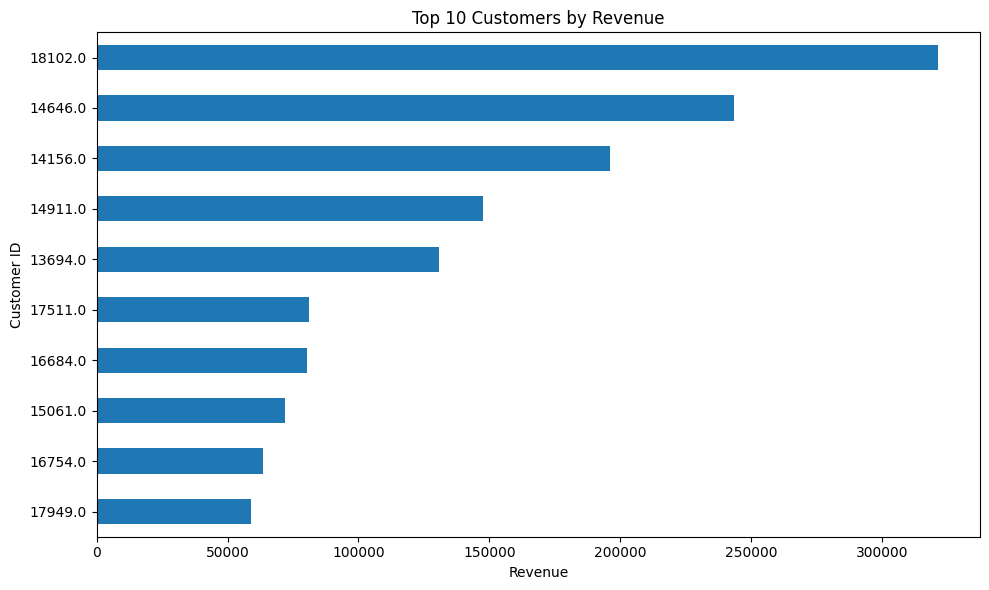

In [ ]:
# Customer spending analysis
top_customers_revenue = (
    customer_df
    .groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_revenue
plt.figure(figsize=(10, 6))

top_customers_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

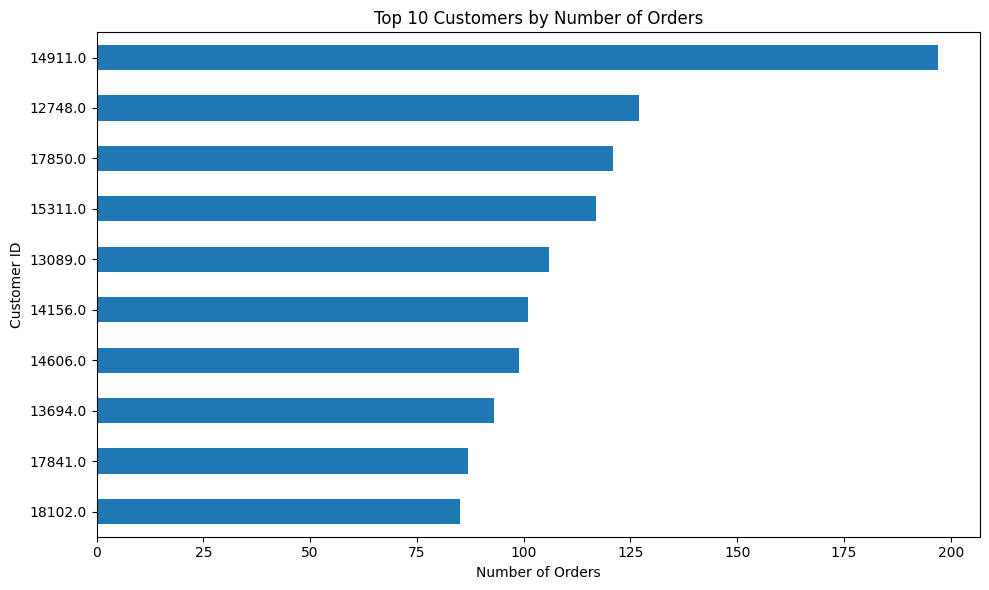

In [ ]:
# Customer purchase frequency
customer_frequency = (
    customer_df
    .groupby('Customer ID')['Invoice']
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.head(10)
top_frequency = customer_frequency.head(10)

plt.figure(figsize=(10, 6))

top_frequency.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

In [ ]:
# Customer revenue distribution
customer_revenue = (
    customer_df
    .groupby('Customer ID')['Revenue']
    .sum()
)

print(customer_revenue.describe())

count      4257.000000
mean       1981.392693
std        8566.762534
min           2.950000
25%         306.000000
50%         681.650000
75%        1658.370000
max      321329.740000
Name: Revenue, dtype: float64


In [ ]:
# Find the analysis date
print("Last transaction date:", customer_df['InvoiceDate'].max())
analysis_date = customer_df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Last transaction date: 2010-11-29 16:41:00
Analysis date: 2010-11-30 16:41:00


In [ ]:
# Calculate Recency
recency = (
    customer_df
    .groupby('Customer ID')['InvoiceDate']
    .max()
    .apply(lambda x: (analysis_date - x).days)
)

recency.head()

,InvoiceDate
Customer ID,
12346.0,155
12347.0,30
12348.0,64
12349.0,33
12351.0,1


In [ ]:
# Calculate Frequency
frequency = (
    customer_df
    .groupby('Customer ID')['Invoice']
    .nunique()
)

frequency.head()

,Invoice
Customer ID,
12346.0,11
12347.0,1
12348.0,1
12349.0,3
12351.0,1


In [ ]:
# Calculate Monetary
monetary = (
    customer_df
    .groupby('Customer ID')['Revenue']
    .sum()
)

monetary.head()

,Revenue
Customer ID,
12346.0,372.86
12347.0,611.53
12348.0,222.16
12349.0,2671.14
12351.0,300.93


In [ ]:
# Create the RFM table
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()
print("Customers:", rfm.shape[0])
print("Features:", rfm.shape[1])

Customers: 4257
Features: 3


In [ ]:
# Understand the RFM distributions
rfm.describe()

,Recency,Frequency,Monetary
count,4257.000000,4257.000000,4257.000000
mean,88.384543,4.302091,1981.392693
std,94.933576,7.740679,8566.762534
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,306.000000
50%,48.000000,2.000000,681.650000
75%,135.000000,5.000000,1658.370000
max,364.000000,197.000000,321329.740000


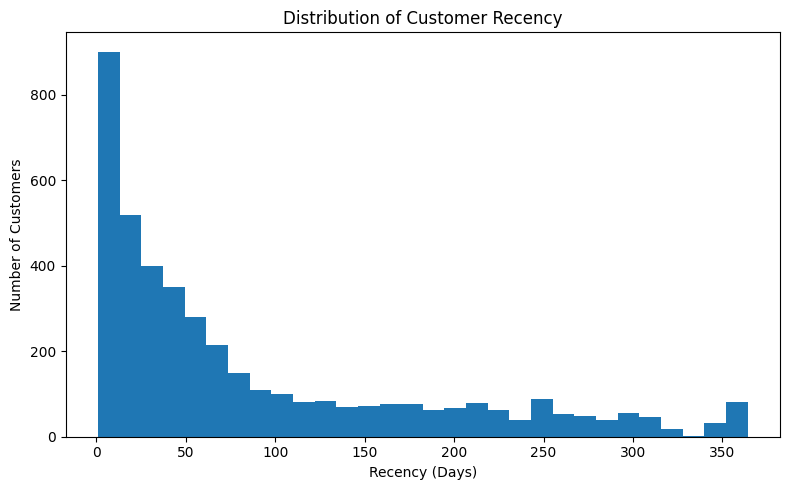

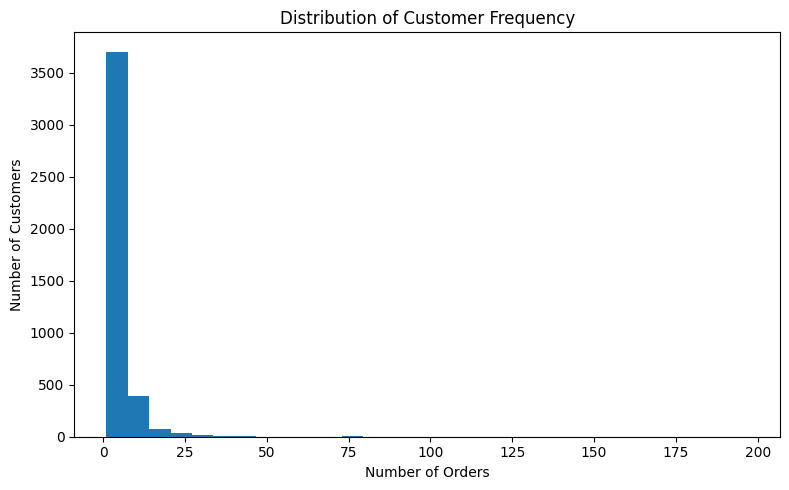

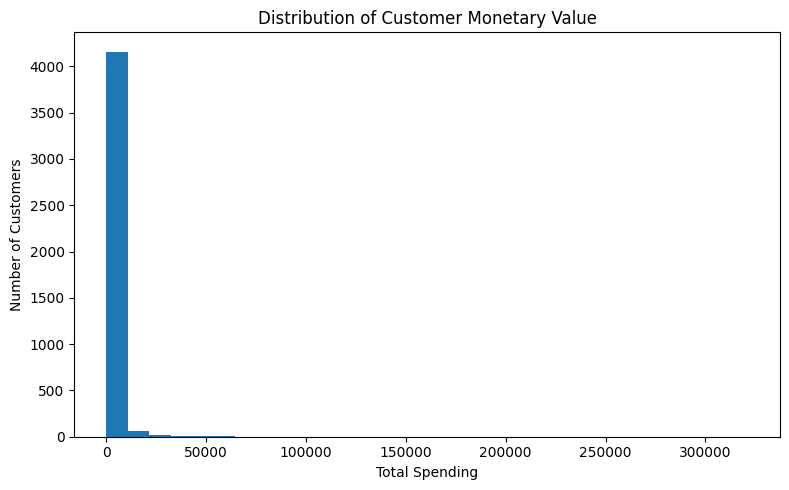

In [ ]:
# Visualize the RFM distributions
# Recency
plt.figure(figsize=(8, 5))

plt.hist(rfm['Recency'], bins=30)

plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()
# Frequency
plt.figure(figsize=(8, 5))

plt.hist(rfm['Frequency'], bins=30)

plt.title('Distribution of Customer Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()
# Monetary
plt.figure(figsize=(8, 5))

plt.hist(rfm['Monetary'], bins=30)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()


In [ ]:
# Apply log transformation
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,5.049856,2.484907,5.923881
12347.0,3.433987,0.693147,6.417598
12348.0,4.174387,0.693147,5.407889
12349.0,3.526361,1.386294,7.890635
12351.0,0.693147,0.693147,5.710195


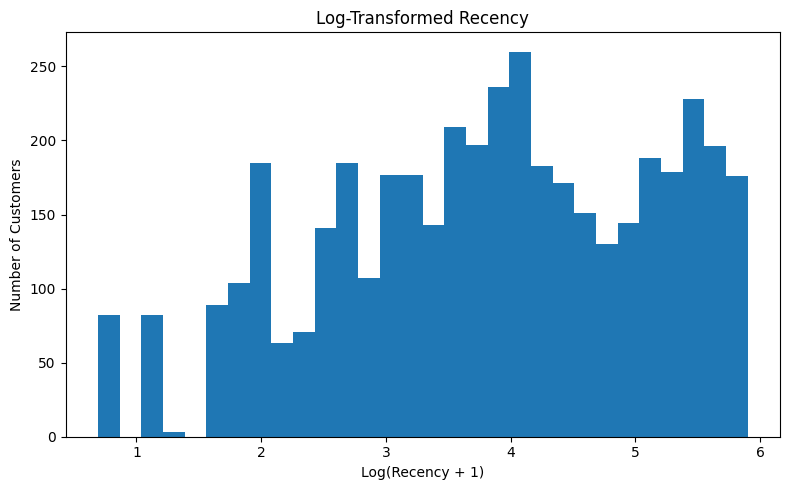

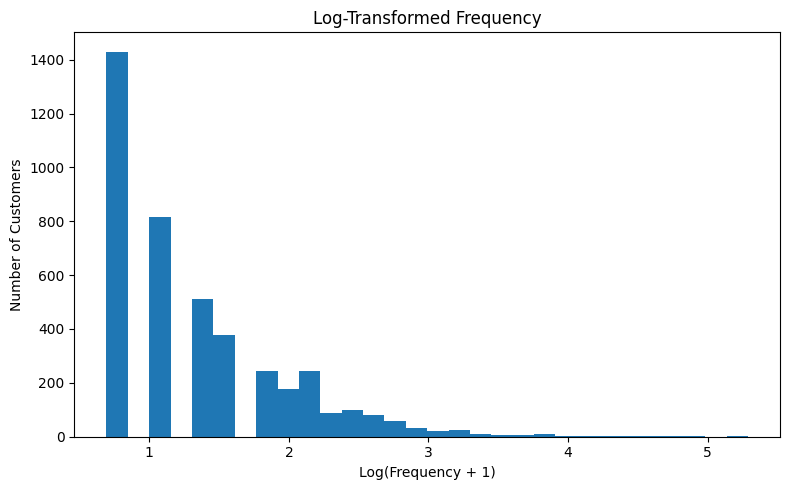

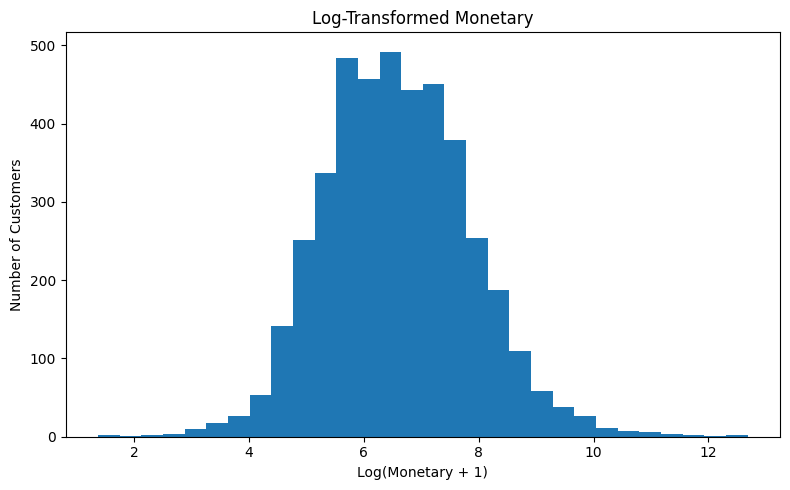

In [ ]:
# Check the transformed distributions
# Recency
plt.figure(figsize=(8, 5))

plt.hist(rfm_log['Recency'], bins=30)

plt.title('Log-Transformed Recency')
plt.xlabel('Log(Recency + 1)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()
# Frequency
plt.figure(figsize=(8, 5))

plt.hist(rfm_log['Frequency'], bins=30)

plt.title('Log-Transformed Frequency')
plt.xlabel('Log(Frequency + 1)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()
# Monetary
plt.figure(figsize=(8, 5))

plt.hist(rfm_log['Monetary'], bins=30)

plt.title('Log-Transformed Monetary')
plt.xlabel('Log(Monetary + 1)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [ ]:
# Standardize the RFM features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm_log.index,
    columns=rfm_log.columns
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.950850,1.667355,-0.523795
12347.0,-0.290522,-0.971607,-0.135692
12348.0,0.278282,-0.971607,-0.929409
12349.0,-0.219557,0.049283,1.022240
12351.0,-2.396138,-0.971607,-0.691770


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

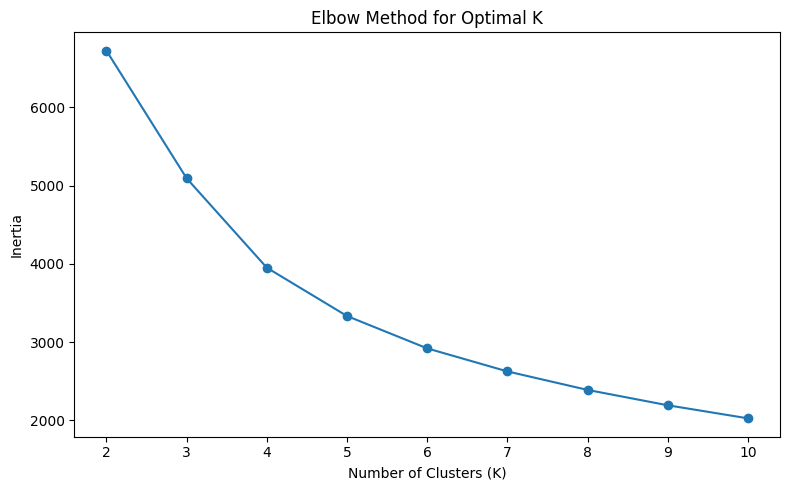

In [ ]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []

K_values = range(2, 11)

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    plt.figure(figsize=(8, 5))

plt.plot(K_values, inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(K_values)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

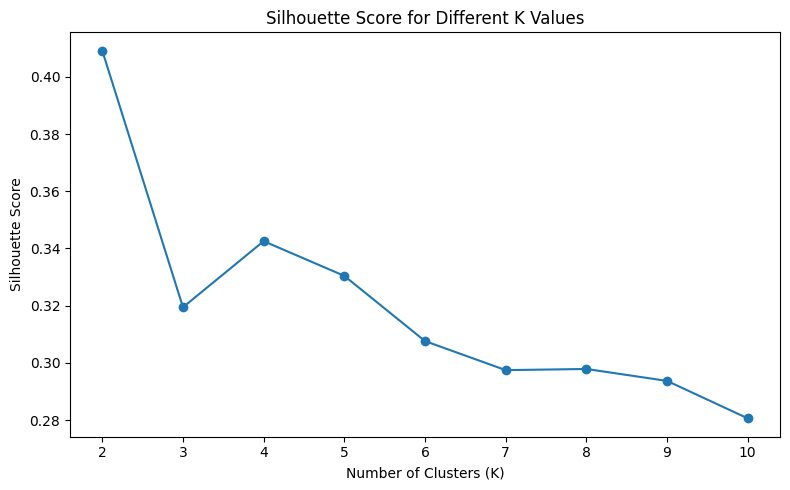

In [ ]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    plt.figure(figsize=(8, 5))

plt.plot(K_values, silhouette_scores, marker='o')

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.xticks(K_values)
plt.tight_layout()
plt.show()

In [ ]:
# Create K=2, K=3 and K=4 clusters
cluster_results = {}

for k in [2, 3, 4]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    temp_rfm = rfm.copy()
    temp_rfm['Cluster'] = labels

    cluster_results[k] = temp_rfm
    # Profile K=2
    cluster_results[2].groupby('Cluster').agg({
    'Recency': ['count', 'mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median']
})
# Profile K=3
cluster_results[3].groupby('Cluster').agg({
    'Recency': ['count', 'mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median']
})
# Profile K=4
cluster_results[4].groupby('Cluster').agg({
    'Recency': ['count', 'mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median']
})


Recency                     Frequency            Monetary          
          count        mean median       mean median         mean    median
Cluster                                                                    
0           755   14.811921   11.0  13.132450    9.0  7227.819653  3412.780
1           942   17.910828   15.0   2.085987    2.0   593.861795   490.270
2          1406  179.866999  176.5   1.287340    1.0   297.982775   257.645
3          1154   82.586655   62.0   4.006932    4.0  1732.585150  1320.150

In [ ]:
# Train our FINAL K-Means model
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = final_labels

print("Final K-Means model trained successfully!")

print(rfm['Cluster'].value_counts().sort_index())

Final K-Means model trained successfully!
Cluster
0     755
1     942
2    1406
3    1154
Name: count, dtype: int64


In [ ]:
# Create business names
cluster_names = {
    0: 'High-Value Loyal',
    1: 'Recent Occasional',
    2: 'At-Risk / Inactive',
    3: 'Regular / Developing'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,155,11,372.86,3,Regular / Developing
12347.0,30,1,611.53,1,Recent Occasional
12348.0,64,1,222.16,2,At-Risk / Inactive
12349.0,33,3,2671.14,3,Regular / Developing
12351.0,1,1,300.93,1,Recent Occasional


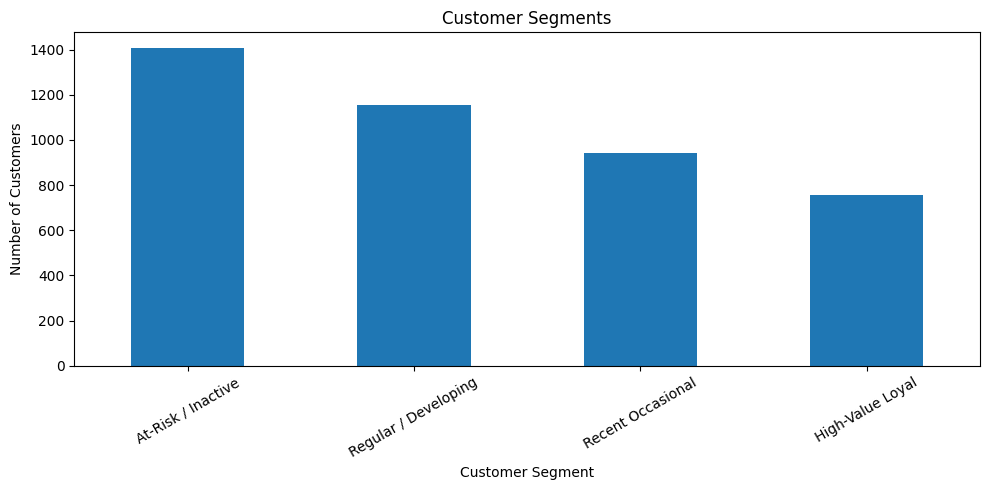

In [ ]:
# Visualize the segments
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))

segment_counts.plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Save our customer segmentation
rfm_path = '/content/drive/MyDrive/ecommerce-ai-ml-project/data/customer_rfm_segments.csv'

rfm.to_csv(rfm_path)

print("RFM segmentation saved successfully!")
print(rfm.shape)
print(rfm['Segment'].value_counts())

RFM segmentation saved successfully!
(4257, 5)
Segment
At-Risk / Inactive      1406
Regular / Developing    1154
Recent Occasional        942
High-Value Loyal         755
Name: count, dtype: int64


In [ ]:
# First, let's understand our date range
print("First transaction:", customer_df['InvoiceDate'].min())
print("Last transaction:", customer_df['InvoiceDate'].max())
print(
    customer_df['InvoiceDate'].dt.to_period('M').value_counts()
    .sort_index()
)


First transaction: 2009-12-01 07:45:00
Last transaction: 2010-11-29 16:41:00
InvoiceDate
2009-12    30272
2010-01    21458
2010-02    23040
2010-03    31782
2010-04    26831
2010-05    28233
2010-06    30688
2010-07    26643
2010-08    26029
2010-09    34128
2010-10    48723
2010-11    56629
Freq: M, Name: count, dtype: int64


In [ ]:
# Create a Prediction Cutoff Date
cutoff_date = pd.Timestamp("2010-10-01")

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2010-10-01 00:00:00


In [ ]:
# Split the Dataset
past_df = customer_df[customer_df['InvoiceDate'] < cutoff_date].copy()

future_df = customer_df[customer_df['InvoiceDate'] >= cutoff_date].copy()

print("Past transactions:", len(past_df))
print("Future transactions:", len(future_df))

Past transactions: 279104
Future transactions: 105352


In [ ]:
# Build Features from Past Data
analysis_date = cutoff_date

features = past_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

features.columns = ["Recency", "Frequency", "Monetary"]

features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,94,11,372.86
12348.0,3,1,222.16
12349.0,135,2,1268.52
12355.0,132,1,488.21
12358.0,115,2,1697.93


In [ ]:
# Create the Target Variable
future_customers = future_df["Customer ID"].unique()

features["RepeatPurchase"] = (
    features.index.isin(future_customers)
).astype(int)

features.head()

,Recency,Frequency,Monetary,RepeatPurchase
Customer ID,,,,
12346.0,94,11,372.86,0
12348.0,3,1,222.16,0
12349.0,135,2,1268.52,1
12355.0,132,1,488.21,0
12358.0,115,2,1697.93,1


RepeatPurchase
0    1838
1    1726
Name: count, dtype: int64


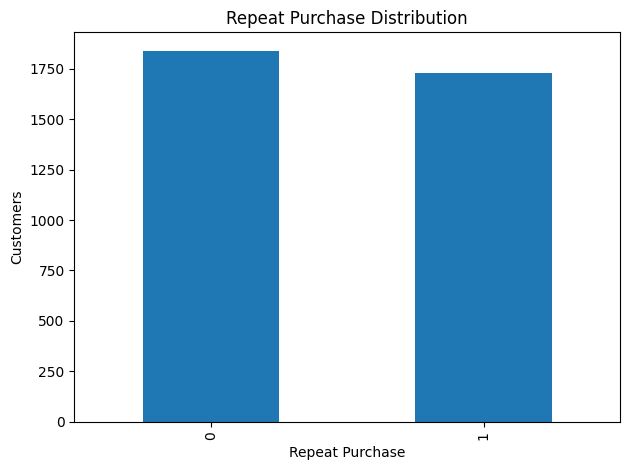

In [ ]:
# Check the Target Distribution
print(features["RepeatPurchase"].value_counts())

features["RepeatPurchase"].value_counts().plot(kind="bar")

plt.title("Repeat Purchase Distribution")
plt.xlabel("Repeat Purchase")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

In [ ]:
# Prepare Features and Target
X = features[['Recency', 'Frequency', 'Monetary']]
y = features['RepeatPurchase']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3564, 3)
Target shape: (3564,)


In [ ]:
# Split the Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 2851
Testing customers: 713


In [ ]:
# Standardize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
# Make Predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluate the Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.667601683029453
Precision: 0.6985294117647058
Recall   : 0.5507246376811594
F1 Score : 0.6158833063209076
ROC-AUC  : 0.7289382482671707

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.78      0.71       368
           1       0.70      0.55      0.62       345

    accuracy                           0.67       713
   macro avg       0.67      0.66      0.66       713
weighted avg       0.67      0.67      0.66       713



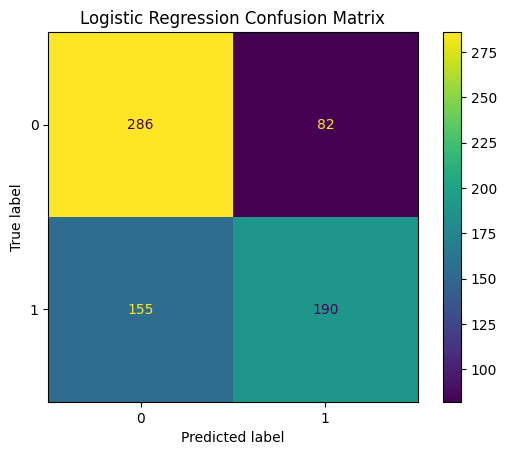

In [ ]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Prepare data and split
from sklearn.model_selection import train_test_split

X = features[['Recency', 'Frequency', 'Monetary']]
y = features['RepeatPurchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Standardize and train Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.667601683029453
Precision: 0.6985294117647058
Recall   : 0.5507246376811594
F1 Score : 0.6158833063209076
ROC-AUC  : 0.7289382482671707


In [ ]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Evaluate Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.6115007012622721
Precision: 0.5994152046783626
Recall   : 0.5942028985507246
F1 Score : 0.5967976710334789
ROC-AUC  : 0.6602945809703844


In [ ]:
# Save the Final Model
import joblib

joblib.dump(model, "/content/drive/MyDrive/ecommerce-ai-ml-project/logistic_regression_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/ecommerce-ai-ml-project/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
# Create Customer–Product Matrix
customer_product = customer_df.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print(customer_product.shape)


(4257, 4009)


In [ ]:
# Train Recommendation Model
from sklearn.metrics.pairwise import cosine_similarity

customer_similarity = cosine_similarity(customer_product)

print("Recommendation model created successfully!")

Recommendation model created successfully!


In [ ]:
# Recommendation Function
import pandas as pd

similarity_df = pd.DataFrame(
    customer_similarity,
    index=customer_product.index,
    columns=customer_product.index
)

def recommend_products(customer_id, top_n=5):
    similar_customer = similarity_df.loc[customer_id].drop(customer_id).idxmax()

    customer_items = set(customer_product.loc[customer_id][customer_product.loc[customer_id] > 0].index)
    similar_items = customer_product.loc[similar_customer]
    similar_items = similar_items[similar_items > 0].sort_values(ascending=False)

    recommendations = [item for item in similar_items.index if item not in customer_items]

    return recommendations[:top_n]


In [ ]:
# Test the Recommendation System
customer_id = customer_product.index[0]

print("Customer:", customer_id)
print("Recommended Products:", recommend_products(customer_id))

Customer: 12346.0
Recommended Products: ['46000M']


In [ ]:
# Save Customer Segments
rfm.to_csv(
    "/content/drive/MyDrive/ecommerce-ai-ml-project/data/customer_rfm_segments.csv",
    index=True
)

In [ ]:
# Save Customer–Product Matrix
customer_product.to_csv(
    "/content/drive/MyDrive/ecommerce-ai-ml-project/data/customer_product_matrix.csv"
)

In [ ]:
# Save Customer Similarity Matrix
similarity_df.to_csv(
    "/content/drive/MyDrive/ecommerce-ai-ml-project/data/customer_similarity_matrix.csv"
)

In [ ]:
# Save a Sample of Recommendations
sample_recommendations = []

for customer in customer_product.index[:20]:
    sample_recommendations.append({
        "Customer ID": customer,
        "Recommended Products": ", ".join(recommend_products(customer))
    })

pd.DataFrame(sample_recommendations).to_csv(
    "/content/drive/MyDrive/ecommerce-ai-ml-project/data/sample_recommendations.csv",
    index=False
)

print("Project outputs saved successfully!")

Project outputs saved successfully!
